In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Transform: converting images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),                               # Converts PIL image to tensor
    transforms.Normalize((0.1307,),(0.3081,))            # Normalize with MNIST mean and std where the values are previously are calculated.
])

# MNIST dataset 
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders — batch the data
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}")  # (1, 28, 28)
print(f"Number of classes: 10 (digits 0-9)")

100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])
Number of classes: 10 (digits 0-9)


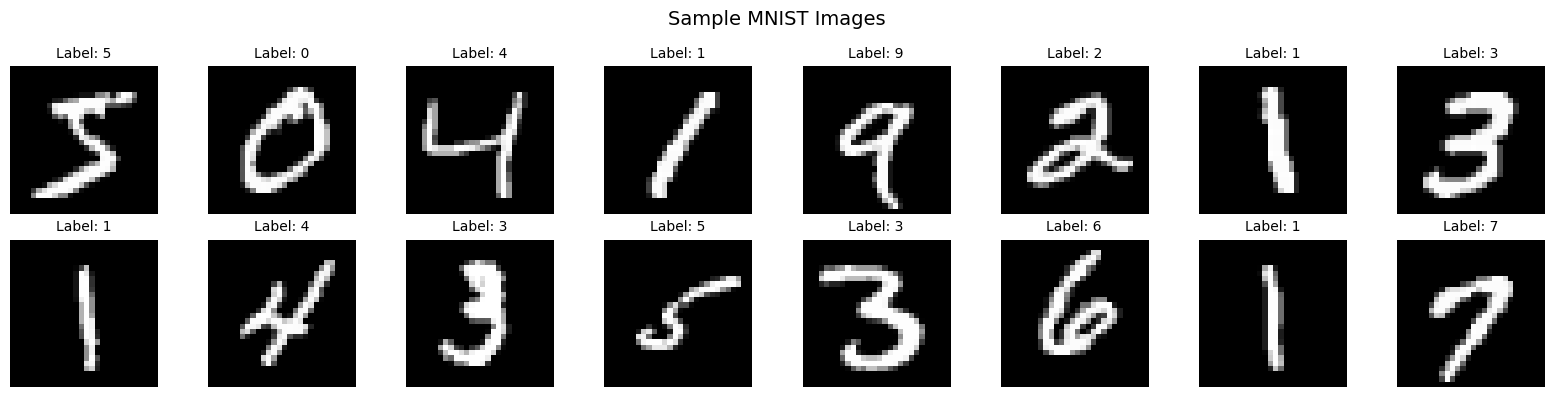


Pixel value range: -0.424 to 2.821
Image shape: torch.Size([1, 28, 28])


In [3]:
# Visualizig the data 

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}", fontsize=10)
    ax.axis('off')

plt.suptitle("Sample MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

# Check the pixel value distribution
sample_image = train_dataset[0][0]
print(f"\nPixel value range: {sample_image.min():.3f} to {sample_image.max():.3f}")
print(f"Image shape: {sample_image.shape}")  # (1, 28, 28) — 1 channel, 28x28


In [10]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,10)
         )
    
    def forward(self, x):
        return self.network(x)

model = MNISTClassifier()
print(model)
print("Total Parameters : ", sum(p.numel() for p in model.parameters()))

MNISTClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)
Total Parameters :  109386


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNISTClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

print("Training on : " , device)

train_losses = []
train_accuracies = []
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):              # Here you need to split the train loader into Images and Labels 
        images,  labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()
    
    epoch_loss     = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch {epoch+1:2d}/{epochs} | "
          f"Loss: {epoch_loss:.4f} | "
          f"Accuracy: {epoch_accuracy:.2f}%")

print("Training Complete.")

Training on :  cuda
Epoch  1/10 | Loss: 0.3458 | Accuracy: 89.41%
Epoch  2/10 | Loss: 0.1696 | Accuracy: 94.89%
Epoch  3/10 | Loss: 0.1341 | Accuracy: 96.00%
Epoch  4/10 | Loss: 0.1143 | Accuracy: 96.48%
Epoch  5/10 | Loss: 0.1012 | Accuracy: 96.90%
Epoch  6/10 | Loss: 0.0921 | Accuracy: 97.08%
Epoch  7/10 | Loss: 0.0873 | Accuracy: 97.25%
Epoch  8/10 | Loss: 0.0777 | Accuracy: 97.49%
Epoch  9/10 | Loss: 0.0760 | Accuracy: 97.61%
Epoch 10/10 | Loss: 0.0689 | Accuracy: 97.83%
Training Complete.


In [15]:
model.eval()
correct = 0
total = 0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs,  1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for label, pred in zip(labels, predicted):
            class_total[label] += 1
            if label == pred :
                class_correct[label] += 1 

overall_accuracy = 100 * correct / total
print(f"Overall Test Accuracy: {overall_accuracy:.2f}%\n")

print("Per-digit accuracy:")
for digit in range(10):
    acc = 100 * class_correct[digit] / class_total[digit]
    bar = "█" * int(acc // 5)
    print(f"  Digit {digit}: {acc:.1f}% {bar}") 

Overall Test Accuracy: 97.68%

Per-digit accuracy:
  Digit 0: 99.2% ███████████████████
  Digit 1: 98.9% ███████████████████
  Digit 2: 98.1% ███████████████████
  Digit 3: 97.7% ███████████████████
  Digit 4: 98.0% ███████████████████
  Digit 5: 97.5% ███████████████████
  Digit 6: 98.5% ███████████████████
  Digit 7: 95.5% ███████████████████
  Digit 8: 97.3% ███████████████████
  Digit 9: 95.9% ███████████████████


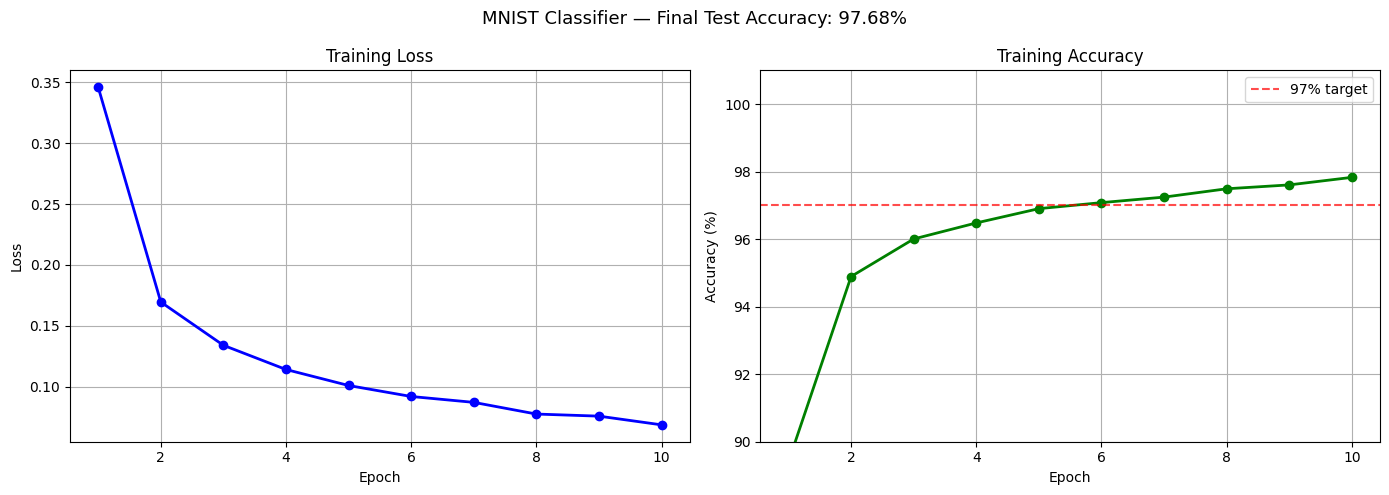

In [16]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs+1), train_losses, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.grid(True)

ax2.plot(range(1, epochs+1), train_accuracies, 'g-o', linewidth=2, markersize=6)
ax2.axhline(y=97, color='red', linestyle='--', alpha=0.7, label='97% target')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training Accuracy")
ax2.set_ylim([90, 101])
ax2.legend()
ax2.grid(True)

plt.suptitle(f"MNIST Classifier — Final Test Accuracy: {overall_accuracy:.2f}%", fontsize=13)
plt.tight_layout()
plt.show()

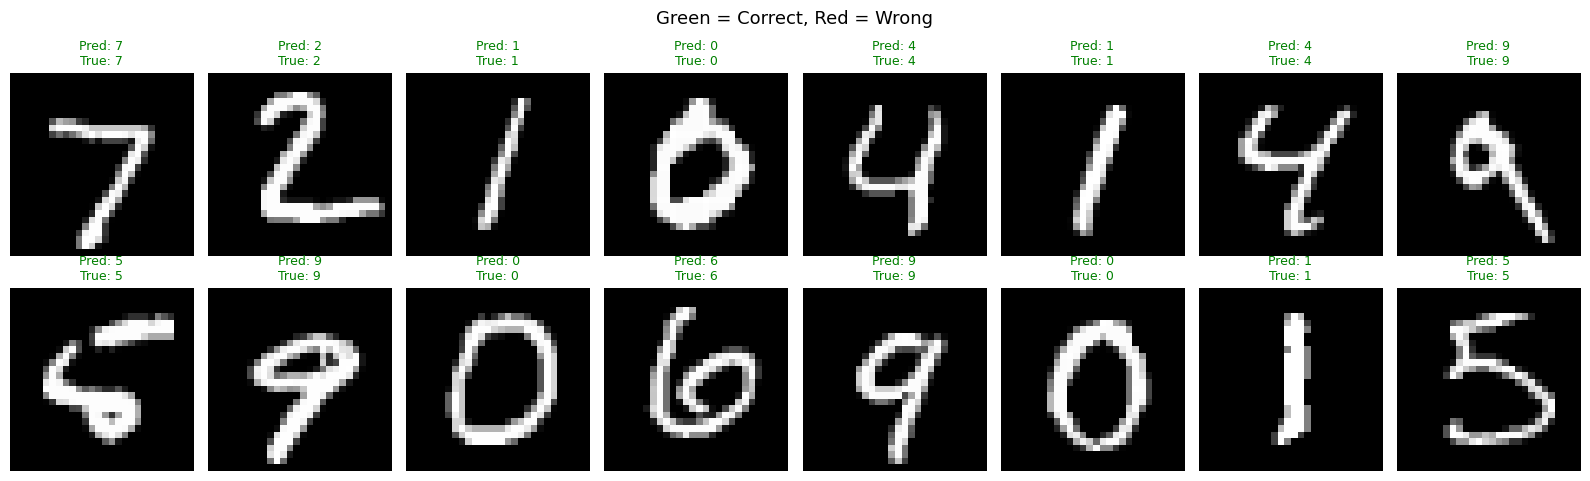

In [17]:
# model predicts on real images
model.eval()

# batch of test images
test_images, test_labels = next(iter(test_loader))
test_images_dev = test_images.to(device)

with torch.no_grad():
    outputs      = model(test_images_dev)
    _, predicted = torch.max(outputs, 1)

# Show 16 predictions
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for i, ax in enumerate(axes.flat):
    image = test_images[i].squeeze().numpy()
    pred  = predicted[i].item()
    true  = test_labels[i].item()
    correct_pred = pred == true

    ax.imshow(image, cmap='gray')
    color = 'green' if correct_pred else 'red'
    ax.set_title(f"Pred: {pred}\nTrue: {true}",
                 color=color, fontsize=9)
    ax.axis('off')

plt.suptitle("Green = Correct, Red = Wrong", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
import os
os.makedirs('projects', exist_ok=True)   
torch.save(model.state_dict(), 'projects/mnist_classifier.pth')
print("Model saved.")


# To load it later:
# model = MNISTClassifier()
# model.load_state_dict(torch.load('projects/mnist_classifier.pth'))
# model.eval()

Model saved.


In [ ]:
# Testing on custom images

from PIL import Image
import torchvision.transforms as transforms
import torch

# Load your custom image
img = Image.open('whatnumber2.png').convert('L')  # 'L' = grayscale

# Apply the SAME transforms used during training
transform = transforms.Compose([
    transforms.Resize((28, 28)),                        # resize to 28x28         
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1 - x),                 # pixel values 0→1
    transforms.Normalize((0.1307,), (0.3081,))          # same normalization
])

img_tensor = transform(img).unsqueeze(0)  # add batch dimension → (1,1,28,28)
img_tensor = img_tensor.to(device)

# Run through model
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    print(f"Model predicts: {predicted.item()}")


Model predicts: 4
